A manufacturing company must satisfy customer demand for 20 industrial components. The company can either:

Manufacture components internally using its own machines.
Purchase components from external suppliers.

Internal manufacturing consumes limited machine hours, while purchased components do not consume capacity.

The objective is to minimize total cost.

In [4]:
import pandas as pd
!apt-get update -qq
!apt-get install -y -qq glpk-utils
import pyomo.environ as pyo


W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu noble InRelease' does not seem to provide it (sources.list entry misspelt?)
Selecting previously unselected package libsuitesparseconfig7:amd64.
(Reading database ... 122809 files and directories currently installed.)
Preparing to unpack .../libsuitesparseconfig7_1%3a7.6.1+dfsg-1build1_amd64.deb ...
Unpacking libsuitesparseconfig7:amd64 (1:7.6.1+dfsg-1build1) ...
Selecting previously unselected package libamd3:amd64.
Preparing to unpack .../libamd3_1%3a7.6.1+dfsg-1build1_amd64.deb ...
Unpacking libamd3:amd64 (1:7.6.1+dfsg-1build1) ...
Selecting previously unselected package libcolamd3:amd64.
Preparing to unpack .../libcolamd3_1%3a7.6.1+dfsg-1build1_amd64.deb ...
Unpacking libcolamd3:amd64 (1:7.6.1+dfsg-1build1) ...
Selecting previously unselected package libglpk40:amd64.
Preparing to unpack .../libglpk40_5.0-1build2_amd64.deb ...
Unpacking libglpk40:amd64 (5.0-1build2) ...
S

In [5]:
from google.colab import files

uploaded = files.upload()


Saving Data .xlsx to Data .xlsx


In [6]:
P=pd.read_excel("Data .xlsx")
P.columns=P.columns.str.strip()
print(list(P.columns))


['Component', 'Demand', 'Make Cost (€)', 'Buy Cost (€)', 'Machine Hours']


**Questions
How many units of each component should be manufactured internally?

How many units should be purchased from suppliers?

Which components are manufactured completely in-house?

Which components are outsourced completely?

Which components use a combination of manufacturing and purchasing?

Total manufacturing cost.

Total purchasing cost.

Total minimum cost.

Machine-hours utilized.

Remaining machine capacity.**

In [7]:
model=pyo.ConcreteModel()
#Sets
model.P=pyo.Set(initialize=P["Component"].tolist())

#Parameters
model.Demand = pyo.Param(
    model.P,
    initialize=P.set_index("Component")["Demand"].to_dict()
)

model.Make_Cost = pyo.Param(
    model.P,
    initialize=P.set_index("Component")["Make Cost (€)"].to_dict()
)

model.Buy_Cost = pyo.Param(
    model.P,
    initialize=P.set_index("Component")["Buy Cost (€)"].to_dict()
)

model.Machine_Hours = pyo.Param(
    model.P,
    initialize=P.set_index("Component")["Machine Hours"].to_dict()
)
#Decision Variable
model.Make=pyo.Var(model.P,within=pyo.NonNegativeIntegers)
model.Buy = pyo.Var(model.P,domain=pyo.NonNegativeIntegers)

#Constraints
def demand_rule(model, p):
    return model.Make[p] + model.Buy[p] == model.Demand[p]

model.DemandConstraint = pyo.Constraint(
    model.P,
    rule=demand_rule
)

def machine_rule(model):
    return sum(
        model.Machine_Hours[p] * model.Make[p]
        for p in model.P
    ) <= 25000

model.MachineConstraint = pyo.Constraint(
    rule=machine_rule
)

#Objective Function
def objective_rule(model):
    return sum(
        model.Make_Cost[p] * model.Make[p]
        +
        model.Buy_Cost[p] * model.Buy[p]
        for p in model.P
    )

model.Objective = pyo.Objective(
    rule=objective_rule,
    sense=pyo.minimize
)

In [8]:
solver=pyo.SolverFactory("glpk")
print("glpk avaliable:",solver.available())
results = solver.solve(model)

print("Status:", results.solver.status)
print("Termination:", results.solver.termination_condition)

glpk avaliable: True
Status: ok
Termination: optimal


In [9]:
#How many units of each component should be manufactured internally?
df = pd.DataFrame({
    "Component": list(model.P),
    "Manufactured": [pyo.value(model.Make[p]) for p in model.P]
})

df
df.style.highlight_max(
    subset=["Manufactured"],color="green").highlight_min(subset=["Manufactured"],color="red")

,Component,Manufactured
0,Motor Housing,1000.000000
1,Gear Shaft,800.000000
2,Bearing Block,1200.000000
3,Pump Casing,0.000000
4,Valve Body,1500.000000
5,Control Unit,0.000000
6,Drive Plate,900.000000
7,Hydraulic Block,0.000000
8,Sensor Housing,1100.000000
9,Power Module,1.000000


In [10]:
#How many units should be purchased from suppliers?
df = pd.DataFrame({
    "Component": list(model.P),
    "Buy": [pyo.value(model.Buy[p]) for p in model.P]
})

df


,Component,Buy
0,Motor Housing,0.0
1,Gear Shaft,0.0
2,Bearing Block,0.0
3,Pump Casing,700.0
4,Valve Body,0.0
5,Control Unit,600.0
6,Drive Plate,0.0
7,Hydraulic Block,750.0
8,Sensor Housing,0.0
9,Power Module,499.0


In [12]:
#Which components are manufactured completely in-house?
results = []

for p in model.P:
    results.append({
        "Component": p,
        "Make": pyo.value(model.Make[p]),
        "Buy": pyo.value(model.Buy[p]),
        "Fully In-House": pyo.value(model.Buy[p]) == 0
    })

df = pd.DataFrame(results)

df

,Component,Make,Buy,Fully In-House
0,Motor Housing,1000.0,0.0,True
1,Gear Shaft,800.0,0.0,True
2,Bearing Block,1200.0,0.0,True
3,Pump Casing,0.0,700.0,False
4,Valve Body,1500.0,0.0,True
5,Control Unit,0.0,600.0,False
6,Drive Plate,900.0,0.0,True
7,Hydraulic Block,0.0,750.0,False
8,Sensor Housing,1100.0,0.0,True
9,Power Module,1.0,499.0,False


In [17]:
for p in model.P:
  if pyo.value(model.Buy[p])==0:
   print(P)

             Component  Demand  Make Cost (€)  Buy Cost (€)  Machine Hours
0        Motor Housing    1000             18            25              2
1           Gear Shaft     800             22            30              3
2        Bearing Block    1200             12            18              1
3          Pump Casing     700             28            36              4
4           Valve Body    1500             10            16              1
5         Control Unit     600             35            45              5
6          Drive Plate     900             16            22              2
7      Hydraulic Block     750             30            40              4
8       Sensor Housing    1100             14            20              2
9         Power Module     500             40            55              6
10      Rotor Assembly     850             26            34              3
11         Stator Core     950             20            28              2
12         Cooling Fan   

In [18]:
#which components use a combination of manufacturing and purchasing?
combo = []

for p in model.P:
    if pyo.value(model.Make[p]) > 0 and pyo.value(model.Buy[p]) > 0:
        combo.append({
            "Component": p,
            "Manufactured": pyo.value(model.Make[p]),
            "Purchased": pyo.value(model.Buy[p])
        })

df_combo = pd.DataFrame(combo)

df_combo

,Component,Manufactured,Purchased
0,Power Module,1.0,499.0
1,Hydraulic Cylinder,236.0,464.0


In [19]:
total_make_cost = sum(
    pyo.value(model.Make[p]) * pyo.value(model.Make_Cost[p])
    for p in model.P
)

print("Total Manufacturing Cost =", total_make_cost)
total_buy_cost = sum(
    pyo.value(model.Buy[p]) * pyo.value(model.Buy_Cost[p])
    for p in model.P
)

print("Total Purchasing Cost =", total_buy_cost)
total_cost = total_make_cost + total_buy_cost

print("Total Minimum Cost =", total_cost)
summary = pd.DataFrame({
    "Metric": [
        "Total Manufacturing Cost",
        "Total Purchasing Cost",
        "Total Minimum Cost"
    ],
    "Value (€)": [
        total_make_cost,
        total_buy_cost,
        total_cost
    ]
})

summary

Total Manufacturing Cost = 208784.0
Total Purchasing Cost = 209541.0
Total Minimum Cost = 418325.0


,Metric,Value (€)
0,Total Manufacturing Cost,208784.0
1,Total Purchasing Cost,209541.0
2,Total Minimum Cost,418325.0


In [20]:
machine_used = sum(
    pyo.value(model.Make[p]) * pyo.value(model.Machine_Hours[p])
    for p in model.P
)

print("Machine-hours utilized:", machine_used)
capacity =25000

remaining_capacity = capacity - machine_used

print("Remaining machine capacity:", remaining_capacity)

Machine-hours utilized: 25000.0
Remaining machine capacity: 0.0


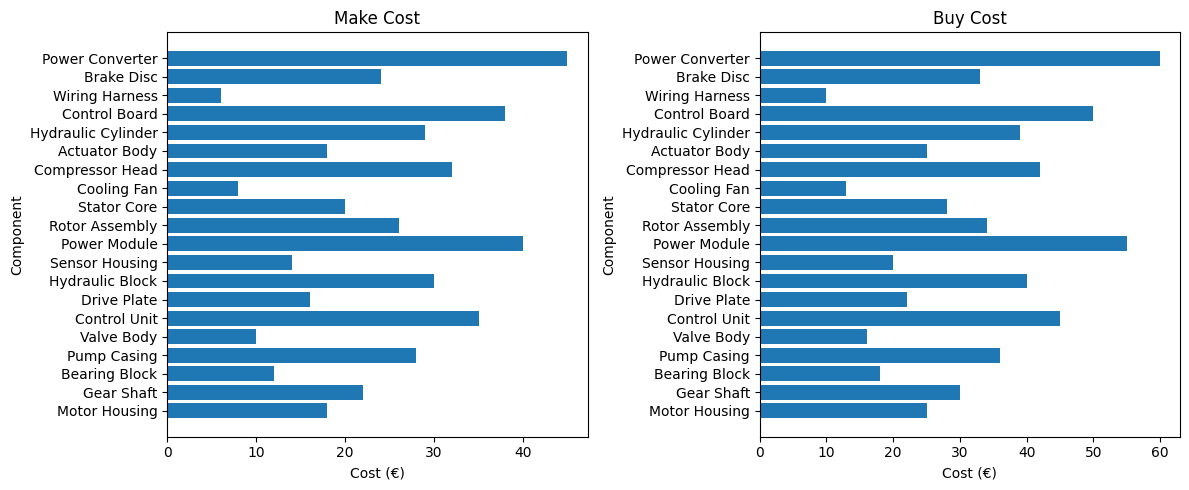

In [28]:
import matplotlib.pyplot as plt

df_cost = pd.DataFrame({
    "Component": list(model.P),
    "Make Cost": [pyo.value(model.Make_Cost[p]) for p in model.P],
    "Buy Cost": [pyo.value(model.Buy_Cost[p]) for p in model.P]
})

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Make Cost
ax[0].barh(df_cost["Component"], df_cost["Make Cost"])
ax[0].set_title("Make Cost")
ax[0].set_xlabel("Cost (€)")
ax[0].set_ylabel("Component")

# Buy Cost
ax[1].barh(df_cost["Component"], df_cost["Buy Cost"])
ax[1].set_title("Buy Cost")
ax[1].set_xlabel("Cost (€)")
ax[1].set_ylabel("Component")

plt.tight_layout()
plt.show()